# Regresión lineal: motivación

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [4.5, 3]

## El problema

Tenemos 100 estudiantes, de los que sabemos:
 * el número de horas que estudiaron para su examen
 * la nota que obtuvieron (de 0 a 100)

In [3]:
data = pd.read_csv("./datasets/hours_vs_mark.csv")

In [4]:
data.shape

(100, 2)

In [5]:
data.head()

,horas,nota
0,865,95
1,4,12
2,305,35
3,437,56
4,682,86


Nos gustaría entender la relación $$nota = f(horas)$$

de manera que podamos **predecir la nota esperada** que obtendremos estudiando un determinado número de horas

## Exploración del data

In [7]:
data.nota.max()

np.int64(100)

In [8]:
data.nota.min()

np.int64(0)

In [9]:
data.nota.mean()

np.float64(47.94)

In [10]:
data.nota.median()

np.float64(44.0)

In [11]:
data.nota.describe()

count    100.000000
mean      47.940000
std       27.757907
min        0.000000
25%       29.500000
50%       44.000000
75%       68.000000
max      100.000000
Name: nota, dtype: float64

In [12]:
import seaborn as sns

<Axes: xlabel='nota', ylabel='Count'>

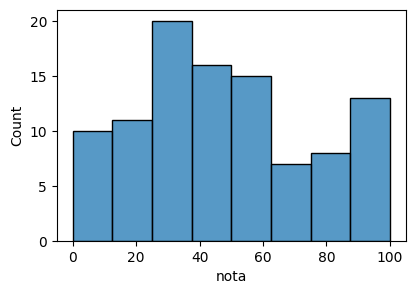

In [13]:
sns.histplot(x=data.nota)

<Axes: xlabel='horas', ylabel='Count'>

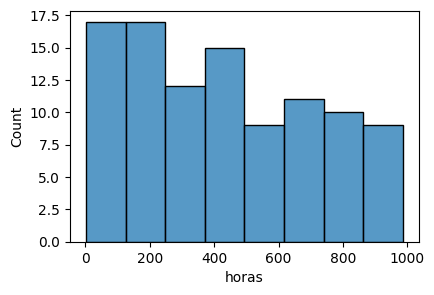

In [14]:
sns.histplot(x=data.horas)

<Axes: xlabel='horas', ylabel='Density'>

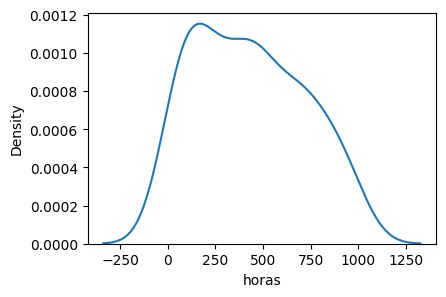

In [15]:
sns.kdeplot(x=data.horas)

<Axes: xlabel='horas', ylabel='nota'>

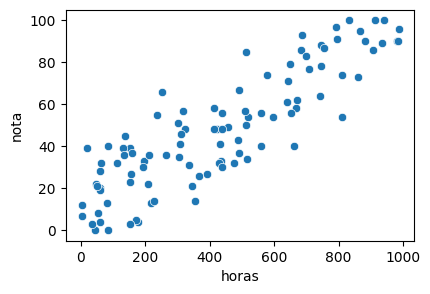

In [16]:
sns.scatterplot(x=data.horas, y=data.nota)

In [17]:
data.corr()

,horas,nota
horas,1.000000,0.867072
nota,0.867072,1.000000


<img width=700 src="https://www.simplypsychology.org/wp-content/uploads/correlation-coefficient.jpg">

## El modelo lineal

Probemos con una relación lineal, $$Y = m * X + n$$

$m$ es la pendiente  
$n$ es el valor de $Y$ cuando $X=0$ 

$$nota = m * horas + n$$

Queremos encontrar los valores de $m$ and $n$ que *mejor* modelan nuestros datos

Conjeturemos:

<Axes: xlabel='horas', ylabel='nota'>

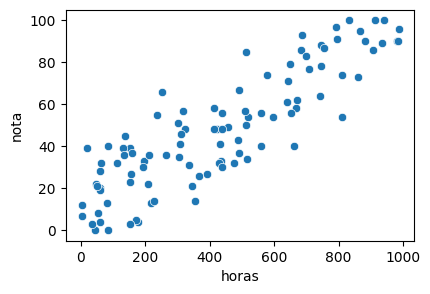

In [16]:
sns.scatterplot(x=data.horas, y=data.nota)

$$nota_1 = 0.1 * horas$$

$$nota_2 = 0.11 * horas + 5$$

Qué modelo lo hace mejor?

In [20]:
data.shape

(100, 2)

In [21]:
data.head()

,horas,nota
0,865,95
1,4,12
2,305,35
3,437,56
4,682,86


In [22]:
data["prediction_1"] = data.horas * 0.1

In [23]:
data["prediction_2"] = data.horas * 0.11 + 5

In [26]:
# semi-random prediction
data["prediction_3"] = np.random.uniform(40, 60, size=data.shape[0]).round(2)

In [27]:
data.head()

,horas,nota,prediction_1,prediction_2,prediction_3
0,865,95,86.5,100.15,59.58
1,4,12,0.4,5.44,54.42
2,305,35,30.5,38.55,46.78
3,437,56,43.7,53.07,48.74
4,682,86,68.2,80.02,46.53


Qué hace a un modelo "mejor"?

Veamos cuál es el error de cada modelo

Utilizaremos el [error cuadrático medio](https://es.wikipedia.org/wiki/Error_cuadr%C3%A1tico_medio)

In [28]:
data['error_1'] = (data.nota - data.prediction_1) ** 2

In [29]:
data['error_2'] = (data.nota - data.prediction_2) ** 2

In [30]:
data['error_3'] = (data.nota - data.prediction_3) ** 2

In [35]:
data.head()

,horas,nota,prediction_1,prediction_2,prediction_3,error_1,error_2,error_3
0,865,95,86.5,100.15,59.58,72.25,26.5225,1254.5764
1,4,12,0.4,5.44,54.42,134.56,43.0336,1799.4564
2,305,35,30.5,38.55,46.78,20.25,12.6025,138.7684
3,437,56,43.7,53.07,48.74,151.29,8.5849,52.7076
4,682,86,68.2,80.02,46.53,316.84,35.7604,1557.8809


In [36]:
data.sample(10)

,horas,nota,prediction_1,prediction_2,prediction_3,error_1,error_2,error_3
80,941,100,94.1,108.51,54.24,34.81,72.4201,2093.9776
35,518,54,51.8,61.98,59.04,4.84,63.6804,25.4016
40,640,61,64.0,75.40,58.16,9.00,207.3600,8.0656
33,579,74,57.9,68.69,57.14,259.21,28.1961,284.2596
99,934,89,93.4,107.74,53.44,19.36,351.1876,1264.5136
65,439,48,43.9,53.29,48.52,16.81,27.9841,0.2704
78,649,79,64.9,76.39,40.98,198.81,6.8121,1445.5204
1,4,12,0.4,5.44,54.42,134.56,43.0336,1799.4564
77,157,27,15.7,22.27,54.50,127.69,22.3729,756.2500
81,491,37,49.1,59.01,56.83,146.41,484.4401,393.2289


In [32]:
data.error_1.mean().round(1)

np.float64(234.8)

In [33]:
data.error_2.mean().round(1)

np.float64(259.8)

In [34]:
data.error_3.mean().round(1)

np.float64(779.0)

Dibujemos las rectas de nuestros modelos

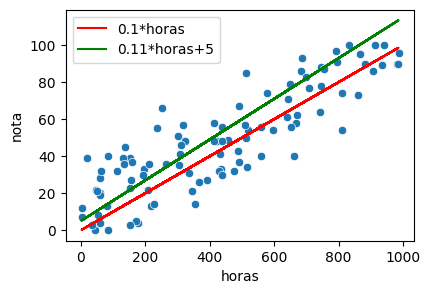

In [37]:
fig, ax = plt.subplots()
sns.scatterplot(x=data.horas, y=data.nota)

plt.plot(data.horas, data.prediction_1, color='r', label='0.1*horas')
plt.plot(data.horas, data.prediction_2, color='g', label='0.11*horas+5')

plt.legend()

In [38]:
data.head()

,horas,nota,prediction_1,prediction_2,prediction_3,error_1,error_2,error_3
0,865,95,86.5,100.15,59.58,72.25,26.5225,1254.5764
1,4,12,0.4,5.44,54.42,134.56,43.0336,1799.4564
2,305,35,30.5,38.55,46.78,20.25,12.6025,138.7684
3,437,56,43.7,53.07,48.74,151.29,8.5849,52.7076
4,682,86,68.2,80.02,46.53,316.84,35.7604,1557.8809


### Entendiendo el error del modelo como una función de `m` y `n`

$$nota = m * horas + n$$

`L` significa Loss (la palabra que se utiliza como "error" en Data Science)

$$Error = L(m, n)$$

$$nota_1 = 0.1 * horas$$

$$L(m=0.1, n=0) = 234$$

$$nota_2 = 0.11 * horas + 5$$

$$L(m=0.11, n=5) = 259$$

In [41]:
data.head()

,horas,nota,prediction_1,prediction_2,prediction_3,error_1,error_2,error_3
0,865,95,86.5,100.15,59.58,72.25,26.5225,1254.5764
1,4,12,0.4,5.44,54.42,134.56,43.0336,1799.4564
2,305,35,30.5,38.55,46.78,20.25,12.6025,138.7684
3,437,56,43.7,53.07,48.74,151.29,8.5849,52.7076
4,682,86,68.2,80.02,46.53,316.84,35.7604,1557.8809


Si llamamos:
 - $y_i$ a la nota real del estudiante $i$
 - $\hat{y_i}$ la nota predicha para el estudiante $i$  

El error es $$L(m, n) = \frac{1}{N} \sum (y_i - \hat{y_i})^2 = \frac{1}{N} \sum (y_i - (m * x_i + n))^2 $$

y siendo cuadrática en `m` y `n`, la función `L` tiene un mínimo global

## El modelo lineal óptimo

Podemos encontrar **el mejor** modelo lineal?

`scikit-learn` es una librería de Python para entrenar modelos

In [ ]:
!pip install scikit-learn

In [43]:
from sklearn.linear_model import LinearRegression

In [44]:
lr = LinearRegression()

In [45]:
lr

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [46]:
data.head()

,horas,nota,prediction_1,prediction_2,prediction_3,error_1,error_2,error_3
0,865,95,86.5,100.15,59.58,72.25,26.5225,1254.5764
1,4,12,0.4,5.44,54.42,134.56,43.0336,1799.4564
2,305,35,30.5,38.55,46.78,20.25,12.6025,138.7684
3,437,56,43.7,53.07,48.74,151.29,8.5849,52.7076
4,682,86,68.2,80.02,46.53,316.84,35.7604,1557.8809


In [51]:
# entrenar el modelo
# X predictores: 1 o más columnas
# y objetivo: 1 columna
lr.fit(
    # X = data[["horas", "edad", "horasdesueño"]],
    X = data[["horas"]],
    y = data.nota,
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


$$nota = m * horas + n$$

In [52]:
# access coefficients m and n. it has 1 entry per predictor variable
lr.coef_

array([0.08437787])

Si tuviéramos 3 predictores en vez de uno, la función sería algo así:
$$nota = m_1 * horas + m_2 * edad + m_3 * horasdesueño + n$$

In [53]:
optimal_m = lr.coef_[0]

In [54]:
optimal_m

np.float64(0.08437787096170372)

In [55]:
optimal_n = lr.intercept_

In [56]:
optimal_n

np.float64(11.78070717807148)

$$nota = 0.084 * horas + 11.8$$

In [57]:
data.head()

,horas,nota,prediction_1,prediction_2,prediction_3,error_1,error_2,error_3
0,865,95,86.5,100.15,59.58,72.25,26.5225,1254.5764
1,4,12,0.4,5.44,54.42,134.56,43.0336,1799.4564
2,305,35,30.5,38.55,46.78,20.25,12.6025,138.7684
3,437,56,43.7,53.07,48.74,151.29,8.5849,52.7076
4,682,86,68.2,80.02,46.53,316.84,35.7604,1557.8809


In [58]:
data["best_prediction"] = (data.horas * optimal_m + optimal_n).round(2)

In [59]:
data["best_prediction_error"] = (data.best_prediction - data.nota) ** 2

In [60]:
data.head()

,horas,nota,prediction_1,prediction_2,prediction_3,error_1,error_2,error_3,best_prediction,best_prediction_error
0,865,95,86.5,100.15,59.58,72.25,26.5225,1254.5764,84.77,104.6529
1,4,12,0.4,5.44,54.42,134.56,43.0336,1799.4564,12.12,0.0144
2,305,35,30.5,38.55,46.78,20.25,12.6025,138.7684,37.52,6.3504
3,437,56,43.7,53.07,48.74,151.29,8.5849,52.7076,48.65,54.0225
4,682,86,68.2,80.02,46.53,316.84,35.7604,1557.8809,69.33,277.8889


In [61]:
data.best_prediction_error.mean()

np.float64(189.308348)

In [63]:
data.error_1.mean()

np.float64(234.8416)

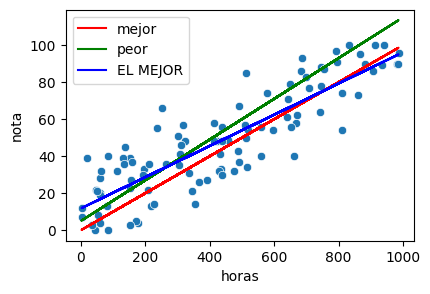

In [65]:
fig, ax = plt.subplots()
sns.scatterplot(x=data.horas, y=data.nota)

plt.plot(data.horas, data.prediction_1, color='r', label='mejor')
plt.plot(data.horas, data.prediction_2, color='g', label='peor')
plt.plot(data.horas, data.best_prediction, color='blue', label='EL MEJOR')

plt.legend()

Utilizando nuestro modelo para hacer predicciones

In [66]:
n_horas = 1000

$$nota = 0.0844*horas + 11.78$$

In [ ]:
optimal_m * n_horas + optimal_n

In [68]:
lr.predict(np.array([[200], [350], [750]])).round(1)

/home/sheriff/.devpy/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([28.7, 41.3, 75.1])

## No todo es lineal

In [70]:
dff = pd.DataFrame({"age": [20, 30, 40, 50, 60, 70, 80], "prob_acc": np.array([1, 0.7, 0.5, 0.4, 0.5, 0.7, 1]) - 0.3})

(0.0, 1.0)

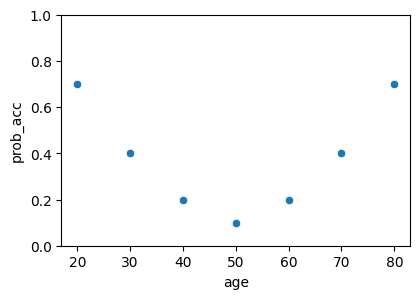

In [71]:
g = sns.scatterplot(x=dff.age, y=dff.prob_acc)
g.set_ylim(0, 1)

$p_{acc} \sim age²$

In [ ]:
dff["age2"] = dff.age ** 2

In [ ]:
lr = LinearRegression()

In [ ]:
lr.fit(
    X=dff[["age", "age2"]],
    y=dff.prob_acc
)

In [ ]:
lr.predict(np.array([[20, 400], [25, 625], [40, 1600], [50, 2500], [60, 3600], [70, 4900], [80, 6400]])).round(2)

In [ ]:
dff.head()

## Alinea tu métrica apropiadamente con el caso de uso

Una métrica mide numéricamente qué tal lo hace un modelo predictivo

Permite comparar dos modelos predictivos

**Motivación**: Somos una empresa que vende tupper de comida preparada cada semana

Tenemos que predecir el número de cajas de comida a preparar cada semana, y esperar que cuadre con la demanda

In [ ]:
data2 = pd.DataFrame({
    "boxes": [100, 150, 160, 90, 220], 
    "pred_kpmg": [105, 153, 172, 93, 244], 
    "pred_accenture": [98, 146, 166, 88, 214]
})

In [ ]:
data2

Qué modelo funciona mejor?

In [ ]:
data2["mse_kpmg"] = (data2["boxes"] - data2["pred_kpmg"]) ** 2
data2["mse_accenture"] = (data2["boxes"] - data2["pred_accenture"]) ** 2

In [ ]:
data2.head()

In [ ]:
data2.mse_kpmg.mean()

In [ ]:
data2.mse_accenture.mean()

Según el criterio (la métrica) del error cuadrático medio (MSE), el modelo de Accenture funciona mejor

**pero**:
 - si hubiéramos obedecido a ese modelo, 4 veces de 5 dejamos a clientes sin servir. Faltarían cajas de comida.
 - si hubiéramos obedecido al otro modelo (KPMG), nunca dejaríamos clientes sin servir. Sobrarían cajas de comida.

Hemos de construir métricas customizadas:

In [ ]:
30 + 30 * 0.95 + 30 * 0.95 * 0.95

$30 (1 + 0.95 + 0.95² + ...) = \frac{30}{1-0.95} = 600$

Si a alguien no le sirvo caja, se va a ir un 30% de las veces

In [ ]:
600 * 0.3

In [ ]:
error_sobra = 3
error_falta = 180

In [ ]:
data2.rename(columns={"pred_kpmg": "pred_1", "pred_accenture": "pred_2"}, inplace=True)

In [ ]:
data2["error_sobra_1"] = (data2["pred_1"] - data2["boxes"]) * (data2["pred_1"] - data2["boxes"] > 0) * error_sobra

In [ ]:
data2["error_falta_1"] = (- data2["pred_1"] + data2["boxes"]) * (data2["pred_1"] - data2["boxes"] < 0) * error_falta

In [ ]:
data2["error_sobra_2"] = (data2["pred_2"] - data2["boxes"]) * (data2["pred_2"] - data2["boxes"] > 0) * error_sobra

In [ ]:
data2["error_falta_2"] = (- data2["pred_2"] + data2["boxes"]) * (data2["pred_2"] - data2["boxes"] < 0) * error_falta

In [ ]:
data2["loss_1"] = data2.error_sobra_1 + data2.error_falta_1
data2["loss_2"] = data2.error_sobra_2 + data2.error_falta_2

In [ ]:
del data2["mse_kpmg"]
del data2["mse_accenture"]

In [ ]:
data2

In [ ]:
data2.loss_1.sum()

In [ ]:
data2.loss_2.sum()

Y, con esta **métrica alineada con el negocio**, el modelo 1 es mejor